In [1]:
import numpy as np
import matplotlib.pyplot as plt

from copy import deepcopy

import copy

# **The Hopfield Network**

**A Hopfield Network is a type of recurrent artificial neural network** that serves as a content-addressable memory system, meaning it can recall stored patterns from incomplete or noisy inputs. Introduced by John Hopfield in 1982 (but very similar ideas were already proposed by Kaoru Nakano in 1971 and Shun'ichi Amari in 1972), these networks are composed of a single layer of interconnected neurons, where each neuron is both an input and output, and connections between them are symmetric; for his foundational contributions to machine learning Hopfield has been awarded the 2024 Nobel Prize in Physics shared with Geoffrey Hinton.  

Hopfield networks store a set of memories $\{ X_i^{(\mu)} \}$ for $\mu \in [1, p]$ and $i \in [1, N]$, where $N$ is the number of pixels of a pattern and $p$ is the number of stored patterns.


In this notebook, **we will define a Python Class to initialise, evolve and visualise Hopfield Networks**. After writing this class, we will test some fundamental results of these networks, like the stability of its fixed points (i.e. the stored patterns). In the final part of the notebook a refined and modern version of the Hopfield Network will be introduced, that will allow us to obtain satisfying results also with more complex patterns. But first...

# A brief introduction to Python Classes 

We want to create a class called 'Hopfield Network' that initialise such a network and implements a variety of useful functions. In a nutshell, a class is a structure that holds together data and functions (called methods).

Classes can be a bit confusing at the beginning, but all you need to understand is that self means literary 'myself', that is, methods (functions) get as first argument the object they are acting on. This means that we can "store" a variable in one method and "retrieve" it in another! No need to pass it around!

Look at the following example code and play with it to make sure you understand how classes works.

In [2]:
class Model:
    # this is a special method that gets called when you create an instance of your class
    def __init__(self, name):
        self.name = name
    
    def set_x(self, x):
        self.x = x
        
    def increment_x(self):
        self.x += 1

    def show_x(self):
        return self.x

In [3]:
# Initialisation of two models
model1 = Model(name="my first model")
model2 = Model(name="another model")

In [4]:
# Using the methods implemented for the class 'Model'
model1.set_x(3)
model2.set_x(-2)

In [5]:
model1.show_x()

3

We can also access information stored in our objects. Notice that our models had a name that was set at initialization.

In [6]:
model1.name

'my first model'

Spend some time playing with this class by implementing new methods and trying them out.

# Exercise 6.1

Now that you have a basic understanding of Python classes, let's focus on Hopfield Networks. Start by creating 5 random patterns with shape 6x6 that the network will store and visualise them.

In [7]:
#Create 5 random patterns
N_patterns = 5
pattern_size = (6, 6)
# store the pattern in a dictionary
random_patterns = {
    f"pattern_{i}": np.random.choice([-1, 1], size=pattern_size)
    for i in range(N_patterns)
}


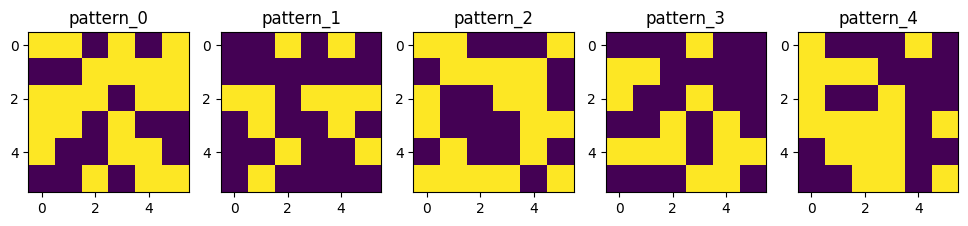

In [8]:
# visualise the patterns
fig, ax = plt.subplots(1, 5, figsize=(12, 8))

for i, pattern in enumerate(random_patterns.items()):
    ax[i].set_title(pattern[0])
    ax[i].imshow(pattern[1])

plt.show()

Let's start to build our HopfieldNetwork class. We start by defining the constructor and implementing a few basic methods that store important information such as:

* `HFN.patterns` is a matrix containing all the patterns in their original shape 
* `HFN.N_neurons` how many neurons the network has 
* `HFN.flat_patterns` is a matrix of stored _flattened_ patterns with shape *(N_patterns, N_neurons)*.
*  ...

In [9]:
class HopfieldNetwork:
    """Base class for our Hopfield Network (Modern) Hopfield Network"""

    def __init__(self, patterns_dict):
        """Initialises the Hopfield network with a set of patterns.
        Args:
            • patterns: a dictionary containing the patterns to be stored in the network labeled by their names. Patterns can be any shape, they will be flattened into vectors during initialisation.
        """
        
        self.patterns_dict = patterns_dict # the entire dictionary
        self.pattern_names = list(patterns_dict.keys()) # the keys of the dictionary
        self.patterns = list(patterns_dict.values()) # the patterns -> the values of the dictionary
        self.pattern_shape = [p.shape for p in self.patterns] # the shape of each pattern
        # Some useful variables
        self.N_neurons = self.patterns[0].size
        self.N_patterns = len(list(self.patterns))
        # Flatten the patterns into a matrix of shape (N_patterns, N_neurons)
        self.flat_patterns = np.array(
            [pattern.ravel() for pattern in self.patterns]
        )

Now you can initialise you Hopfield Network! 

In [10]:
# Call the class you just defined
HFN = HopfieldNetwork(random_patterns)

## Exercise 6.2

Let's store another important element: the weights matrix. Remember that the weights matrix is defined as $J_{ij} = \frac{1}{N}\sum_{\mu=1}^px_i^{\mu}x_j^{\nu}$. 

We copy the class previously written and we add the new lines; 'self.w' must store the weights matrix, with shape N x N, where N is the number of neurons.

In [11]:
class HopfieldNetwork:
    """Base class for our Hopfield Network (Modern) Hopfield Network"""

    def __init__(self, patterns_dict):
        self.patterns_dict = patterns_dict # the entire dictionary
        self.pattern_names = list(patterns_dict.keys()) # the keys of the dictionary
        self.patterns = list(patterns_dict.values()) # the patterns -> the values of the dictionary
        self.pattern_shape = [p.shape for p in self.patterns] # the shape of each pattern
        # Some useful variables
        self.N_neurons = max(p.size for p in self.patterns)
        self.N_patterns = len(list(self.patterns))
        # Flatten the patterns into a matrix of shape (N_patterns, N_neurons)
        self.flat_patterns = np.array(
            [pattern.ravel() for pattern in self.patterns]
        )
        # Initialise the weights and state of the network

        self.w = np.zeros((self.N_neurons, self.N_neurons))

        for p in self.flat_patterns:
            self.w += np.outer(p, p)

        self.w /= self.N_neurons

        # zero out diagonal (common in Hopfield nets)
        np.fill_diagonal(self.w, 0)


In [12]:
HFN = HopfieldNetwork(random_patterns)

In [13]:
### You can access and print the stored weights
HFN.w

array([[ 0.        ,  0.08333333, -0.08333333, ...,  0.02777778,
        -0.02777778,  0.13888889],
       [ 0.08333333,  0.        , -0.02777778, ..., -0.02777778,
         0.02777778,  0.08333333],
       [-0.08333333, -0.02777778,  0.        , ..., -0.08333333,
        -0.02777778, -0.08333333],
       ...,
       [ 0.02777778, -0.02777778, -0.08333333, ...,  0.        ,
        -0.02777778,  0.02777778],
       [-0.02777778,  0.02777778, -0.02777778, ..., -0.02777778,
         0.        , -0.02777778],
       [ 0.13888889,  0.08333333, -0.08333333, ...,  0.02777778,
        -0.02777778,  0.        ]], shape=(36, 36))

## Exercise 6.3
We now define two new methods: *set_state* and *update_state*. 
*set_state* sets the state of the Hopfield network. We want the method to define the state as the pattern provided to the function.
If no pattern is provided, we define the state as a random pattern.
*update_state* updates the state of the network. The update can be asynchronous (one neuron updated at a time) or synchronous (all neurons updated at once)

In [14]:
class HopfieldNetwork:
    """Base class for our Hopfield Network (Modern) Hopfield Network"""

    def __init__(self, patterns_dict):
        """Initialises the Hopfield network with a set of patterns."""
        self.patterns_dict = patterns_dict # the entire dictionary
        self.pattern_names = list(patterns_dict.keys()) # the keys of the dictionary
        self.patterns = list(patterns_dict.values()) # the patterns -> the values of the dictionary
        self.pattern_shape = [p.shape for p in self.patterns] # the shape of each pattern
        # Some useful variables
        self.N_neurons = max(p.size for p in self.patterns)
        self.N_patterns = len(list(self.patterns))
        # Flatten the patterns into a matrix of shape (N_patterns, N_neurons)
        self.flat_patterns = np.array(
            [pattern.ravel() for pattern in self.patterns]
        )
        # Initialise the weights and state of the network
        self.w = np.zeros((self.N_neurons, self.N_neurons))

        for p in self.flat_patterns:
            self.w += np.outer(p, p)

        self.w /= self.N_neurons

        # zero out diagonal
        np.fill_diagonal(self.w, 0)
        self.set_state(random=True)  # initialises the state of the network

    # =================== INITIALISE AND UPDATE NETWORK STATE  ======================
    def set_state(self, state=None, random=False):
        """Sets the state of the Hopfield network. If random = True, sets state to a random vector"""
        if random:
            self.state = np.random.choice([-1, 1], size=self.N_neurons)
        else:
            self.state = state.copy()

    def update_state(self, asynchronous=True):
        # asyncronous updates one neuron at a time
        if asynchronous == True:
            i = np.random.randint(0, self.N_neurons) # choose a random neuron
            self.state[i] = np.sign(np.dot(self.w[i], self.state))  # update the neuron
            if self.state[i] == 0:  # fix zeros
                self.state[i] = 1 

        # synchronous updates all neurons at once
        elif asynchronous == False:
            self.state = np.sign(self.w @ self.state)
            self.state[self.state == 0] = 1 # fix zeros

In [15]:
HFN = HopfieldNetwork(random_patterns)

## Exercise 6.4 
Implement two new methods: 'get_similarities' and 'get_energy'. You just need to complete the new methods inserted below, read the initial comment to better understand what you have to do.


In [16]:
class HopfieldNetwork:
    """Base class for our Hopfield Network (Modern) Hopfield Network"""

    def __init__(self, patterns_dict):
        """Initialises the Hopfield network with a set of patterns."""
        self.patterns_dict = patterns_dict # the entire dictionary
        self.pattern_names = list(patterns_dict.keys()) # the keys of the dictionary
        self.patterns = list(patterns_dict.values()) # the patterns -> the values of the dictionary
        self.pattern_shape = [p.shape for p in self.patterns] # the shape of each pattern
        # Some useful variables
        self.N_neurons = max(p.size for p in self.patterns)
        self.N_patterns = len(list(self.patterns))
        # Flatten the patterns into a matrix of shape (N_patterns, N_neurons)
        self.flat_patterns = np.array(
            [pattern.ravel() for pattern in self.patterns]
        )
        # Initialise the weights and state of the network
        self.w = np.zeros((self.N_neurons, self.N_neurons))

        for p in self.flat_patterns:
            self.w += np.outer(p, p)

        self.w /= self.N_neurons

        # zero out diagonal
        np.fill_diagonal(self.w, 0)
        # self.set_state(random=True)  # initialises the state of the network

    # =================== INITIALISE AND UPDATE NETWORK STATE  ======================
    def set_state(self, state=None, random=False):
        """Sets the state of the Hopfield network. If random = True, sets state to a random vector"""
        if random:
            self.state = np.random.choice([-1, 1], size=self.N_neurons)
        else:
            self.state = state.copy()

    def update_state(self, asynchronous=True):
        # asyncronous updates one neuron at a time
        if asynchronous == True:
            i = np.random.randint(0, self.N_neurons) # choose a random neuron
            self.state[i] = np.sign(np.dot(self.w[i], self.state))  # update the neuron
            if self.state[i] == 0:  # fix zeros
                self.state[i] = 1 

        # synchronous updates all neurons at once
        elif asynchronous == False:
            self.state = np.sign(self.w @ self.state)
            self.state[self.state == 0] = 1 # fix zeros

    def get_similarities(self, state=None):
        """Compares the state (defaults to the current state of the network) to all stored patterns and returns a measure of similarity between the current state and each stored pattern.
        This measure is taken as cos(theta) where theta is the angle between the current state vector and the stored pattern vector in N-D space. 
        You basically perform a dot product between your state and each one of the stored patterns, divided by the norm of your state and by the norm of the stored pattern.
        """
        state = self.state if state is None else state.copy()
        similarities = [
            np.dot(state, p) / (np.linalg.norm(state) * np.linalg.norm(p))
            for p in self.flat_patterns
        ]
        return similarities

    def get_energy(self, state=None):
        """Returns the energy of the network at a given state"""
        state = self.state if state is None else state.copy()
        return -0.5 * state.T @ self.w @ state

## Exercise 6.5
Let's define a new method 'save_history' which saves some info inside a new variable called 'history'. 
This history must be updated, so you need to implement new lines also in other methods: 'set_state'and 'update_state'.

In [17]:
class HopfieldNetwork:
    """Base class for our Hopfield Network (Modern) Hopfield Network"""

    def __init__(self, patterns_dict):
        """Initialises the Hopfield network with a set of patterns."""
        self.patterns_dict = patterns_dict # the entire dictionary
        self.pattern_names = list(patterns_dict.keys()) # the keys of the dictionary
        self.patterns = list(patterns_dict.values()) # the patterns -> the values of the dictionary
        self.pattern_shape = [p.shape for p in self.patterns] # the shape of each pattern
        # Some useful variables
        self.N_neurons = max(p.size for p in self.patterns)
        self.N_patterns = len(list(self.patterns))
        # Flatten the patterns into a matrix of shape (N_patterns, N_neurons)
        self.flat_patterns = np.array(
            [pattern.ravel() for pattern in self.patterns]
        )
        # Initialise the weights and state of the network
        self.w = np.zeros((self.N_neurons, self.N_neurons))

        for p in self.flat_patterns:
            self.w += np.outer(p, p)

        self.w /= self.N_neurons
        np.fill_diagonal(self.w, 0)
        # self.set_state(random=True)  # initialises the state of the network
        # Initialises a history dictionary
        self.history = {"state": [], "similarities": [], "energy": []}

    # =================== INITIALISE AND UPDATE NETWORK STATE  ======================
    def set_state(self, state=None, random=False):
        """Sets the state of the Hopfield network. If random = True, sets state to a random vector"""
        if random:
            self.state = np.random.choice([-1, 1], size=self.N_neurons)
        else:
            self.state = state.copy()
        self.save_history()

    def update_state(self, asynchronous=True):
        # asyncronous updates one neuron at a time
        if asynchronous is True:
            i = np.random.randint(0, self.N_neurons) # choose a random neuron
            self.state[i] = np.sign(np.dot(self.w[i], self.state))  # update the neuron
            if self.state[i] == 0:  # fix zeros
                self.state[i] = 1 

        # synchronous updates all neurons at once
        elif asynchronous is False:
            self.state = np.sign(self.w @ self.state)
            self.state[self.state == 0] = 1 # fix zeros

        self.save_history()  # this saves the history of the network so we can analyse it later once it's all been done

    # =================== ANALYSIS AND HISTORY FUNCTIONS ======================
    def save_history(self):
        """Calculates energy and similarites then saves everything to the history of the Hopfield network"""
        self.similarities = self.get_similarities(self.state)
        self.energy = self.get_energy(self.state)

        # Now save the state, the similarities and the energy inside the new 'history variable' defined in the constructor
        self.history['state'].append(self.state.copy())
        self.history['similarities'].append(self.similarities)
        self.history['energy'].append(self.energy)

    def get_similarities(self, state=None):
        state = self.state if state is None else state.copy()
        similarities = [
            np.dot(state, p) / (np.linalg.norm(state) * np.linalg.norm(p))
            for p in self.flat_patterns
        ]
        return similarities


    def get_energy(self, state=None):
        """Returns the energy of the network at a given state"""
        state = self.state if state is None else state.copy()
        return -0.5 * state.T @ self.w @ state


## Exercise 6.6
We are almost done creating our class! Let's add just a few methods to visualise the results. In the file 'utils.py' you'll find three functions already implemented, so you do not need to write the code yourself. You can import those functions and use them to define three new methods for your class. 

In [18]:
#### IMPORT THE FUCTIONS DEFINED IN 'utils.py' ####
from utils import *

In [19]:
import matplotlib.animation as animation
class HopfieldNetwork:
    """Base class for our Hopfield Network (Modern) Hopfield Network"""

    def __init__(self, patterns_dict):
        """Initialises the Hopfield network with a set of patterns."""
        self.patterns_dict = patterns_dict # the entire dictionary
        self.pattern_names = list(patterns_dict.keys()) # the keys of the dictionary
        self.patterns = list(patterns_dict.values()) # the patterns -> the values of the dictionary
        self.pattern_shape = [p.shape for p in self.patterns] # the shape of each pattern
        # Some useful variables
        self.N_neurons = max(p.size for p in self.patterns)
        self.N_patterns = len(list(self.patterns))
        # Flatten the patterns into a matrix of shape (N_patterns, N_neurons)
        self.flat_patterns = np.array(
            [pattern.ravel() for pattern in self.patterns]
        )
        # Initialise the weights and state of the network
        self.w = np.zeros((self.N_neurons, self.N_neurons))

        for p in self.flat_patterns:
            self.w += np.outer(p, p)

        self.w /= self.N_neurons
        np.fill_diagonal(self.w, 0)
        # Initialises a history dictionary
        self.history = {"state": [], "similarities": [], "energy": []}
        
        # self.set_state(None)  # initialises the state of the network


    # =================== INITIALISE AND UPDATE NETWORK STATE  ======================
    def set_state(self, state=None, random=False):
        """Sets the state of the Hopfield network. If random = True, sets state to a random vector"""
        if random:
            self.state = np.random.choice([-1, 1], size=self.N_neurons)
        else:
            self.state = state.copy()
        self.save_history()

    def update_state(self, asynchronous=True):
        # asyncronous updates one neuron at a time
        if asynchronous is True:
            i = np.random.randint(0, self.N_neurons) # choose a random neuron
            self.state[i] = np.sign(np.dot(self.w[i], self.state))  # update the neuron
            if self.state[i] == 0:  # fix zeros
                self.state[i] = 1 

        # synchronous updates all neurons at once
        elif asynchronous is False:
            self.state = np.sign(self.w @ self.state)
            self.state[self.state == 0] = 1 # fix zeros
        
        self.save_history()

    # =================== ANALYSIS AND HISTORY FUNCTIONS ======================
    def save_history(self):
        """Calculates energy and similarites then saves everything to the history of the Hopfield network"""
        self.similarities = self.get_similarities(self.state)
        self.energy = self.get_energy(self.state)

        # Now save the state, the similarities and the energy inside the new 'history variable' defined in the constructor
        self.history['state'].append(self.state.copy())
        self.history['similarities'].append(self.similarities)
        self.history['energy'].append(self.energy)

    def get_similarities(self, state=None):
        state = self.state if state is None else state.copy()
        similarities = [
            np.dot(state, p) / (np.linalg.norm(state) * np.linalg.norm(p))
            for p in self.flat_patterns
        ]
        return similarities

    def get_energy(self, state=None):
        """Returns the energy of the network at a given state"""
        state = self.state if state is None else state.copy()
        return -0.5 * state.T @ self.w @ state

    # =================== PLOTTING FUNCTIONS ==============================
    def visualise(self, steps_back=0, fig=None, ax=None, title=None):
        """Visualises the state of the Hopfield network n_steps back (defaults to steps_back=0, i.e. current state)"""
        if fig is None or ax is None:
            fig, ax = plt.subplots(1, 1)
        ax.set_title(f'state {steps_back} steps back' if title is None else title)
        idx = -1 if steps_back == 0 else -1 - steps_back
        state = self.history['state'][idx].reshape(self.pattern_shape[0])
        ax.imshow(state, cmap='gray')
        return fig, ax

    def plot_energy(self, n_steps=None):
        """Plots the energy of the Hopfield network over time. n_steps=None defaults to _all_ steps"""
        fig, ax = plt.subplots(1, 1)
        n_steps = len(self.history['energy']) if n_steps is None else n_steps
        ax.set_title(f'Energy evolution over {n_steps} steps')
        ax.plot(np.arange(n_steps), self.history['energy'][:n_steps])
        return fig, ax

    def animate(self, n_steps=10, fps=10, animation_length_secs=5):
        """Animates the last n_steps of the Hopfield network. fps gives frames per second of resulting animation"""
        fig, ax = plt.subplots(1, 1)

        # how many frames we actually show
        total_history = len(self.history['state'])
        n_steps = min(n_steps, total_history)

        frames = self.history['state'][-n_steps:]

        # reshape first frame to get image shape
        img_shape = self.pattern_shape[0]

        im = ax.imshow(frames[0].reshape(img_shape), cmap='gray', vmin=-1, vmax=1)
        ax.set_title("Hopfield dynamics")

        def update(frame):
            im.set_data(frame.reshape(img_shape))
            return [im]

        interval = 1000 / fps  # ms between frames

        anim = animation.FuncAnimation(
            fig,
            update,
            frames=frames,
            interval=interval,
            blit=False
        )

        return anim

In [20]:
HFN = HopfieldNetwork(random_patterns)

# FIXED POINTS

## Exercise 6.7

In class we proved that the stored patterns are fixed points of the dynamics, meaning that the system will evolve towards one of the stored patterns starting from any configuration. In particular, if the system is initialised as one of the stored states, it will stay in that configuration. Check if this is true by visualising the starting state and the state after several updates (apply several times the *update_state* method that you defined). You can also check that the energy of the system is constant. Use the *visualise* and *plot_energy* methods that you defined in your class.

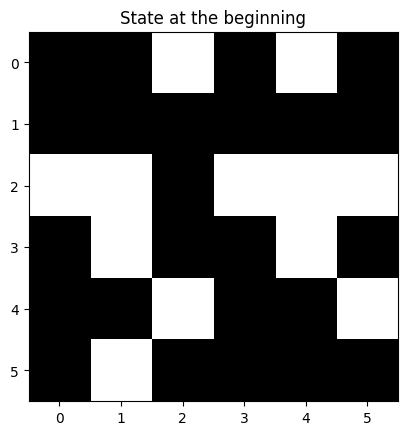

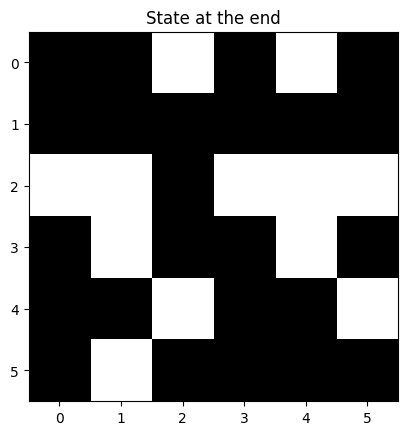

In [21]:
pattern = random_patterns['pattern_1']
HFN.set_state(pattern.ravel())
fig, ax = HFN.visualise(title="State at the beginning")

for _ in range(199):
    HFN.update_state()

fig, ax = HFN.visualise(title="State at the end")
plt.show()

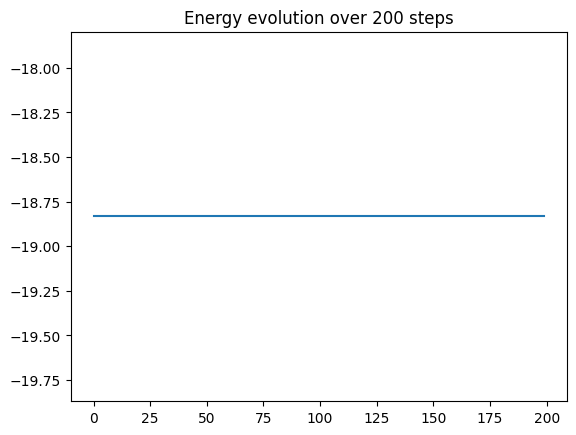

In [22]:
### You can also visualise the time evolution of the energy function
fig, ax = HFN.plot_energy(n_steps=200)

## Exercise 6.8

Do the same but starting from a random configuration. Check that the system evolves towards one of the stored patterns and that the energy decreases until a minimum is reached.

Did not converge to any known state


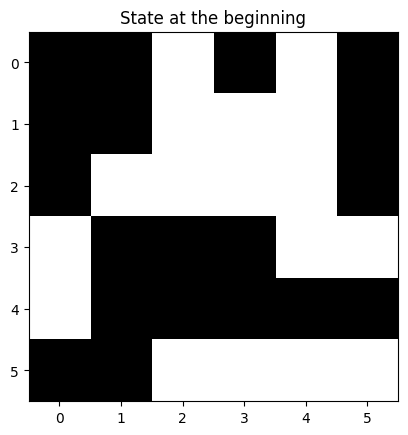

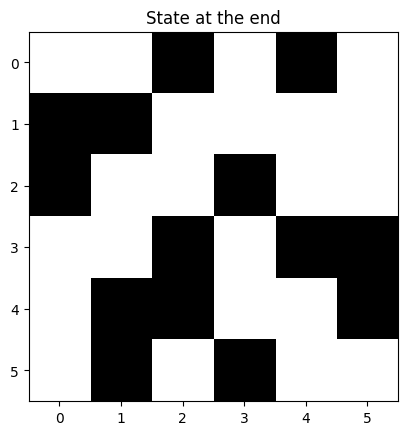

In [23]:
pattern_rand = np.random.choice([-1, 1], (36, ))
HFN = HopfieldNetwork(random_patterns)

HFN.set_state(pattern_rand.ravel())
fig, ax = HFN.visualise(title="State at the beginning")

for _ in range(199):
    HFN.update_state()

fig, ax = HFN.visualise(title="State at the end")

ending_state = HFN.state
found = None
for n, p in random_patterns.items():
    if np.array_equal(p.ravel(), ending_state):
        print(f"Converged to {n}")
        found = True
        break

if not found:
    print("Did not converge to any known state")

plt.show()

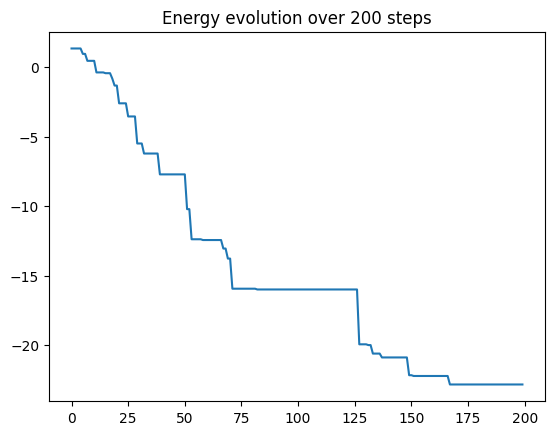

In [24]:
fig, ax = HFN.plot_energy(n_steps=200)

# IMAGE RECOGNITION

## Exercise 6.9

One of the applications of the Hopfield Network is image recognition. By starting from a pattern which is 'similar' to one of the stored ones, the system should evolve towards that state; it is essentially 'recognising' the picture. Try to add some 'noise' to one of the stored patterns and then use this noisy pattern as the starting state. Check that the network correctly evolves towards the right pattern. At what level of noise the network starts to fail? 

Converged to pattern_2


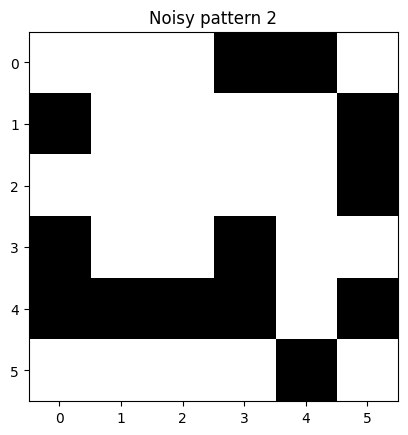

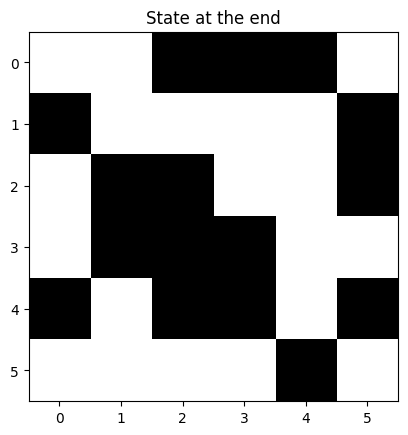

In [25]:
pattern_to_start = random_patterns['pattern_2']
X = 20 # percentage of bits to flip 

#add some noise to the starting pattern
noisy_state = pattern_to_start.ravel().copy()
idx = np.random.choice(pattern_to_start.size, int(pattern_to_start.size * X/100), replace=False)
noisy_state[idx] *= -1

#reinitialise the state of the network, evolve it for several steps and then visualise 

HFN1 = HopfieldNetwork(random_patterns)

HFN1.set_state(noisy_state)
fig, ax = HFN1.visualise(title="Noisy pattern 2")

for _ in range(199):
    HFN1.update_state()

fig, ax = HFN1.visualise(title="State at the end")

ending_state = HFN1.state
found = None
for n, p in random_patterns.items():
    if np.array_equal(p.ravel(), ending_state):
        print(f"Converged to {n}")
        found = True
        break

if not found:
    print("Did not converge to any known state")

plt.show()

## Exercise 6.10

Can the Hopfield Network recognise an image if only a small part of it is provided? For instance, is it able to recognise an image if we provide only the upper left corner? To check, you first need to write a function that masks the given pattern. Complete the function below and then use it to check if the network can recognise one of the stored patterns using only one corner.

In [26]:
def apply_mask(pattern):
    """Masks 75% of the pattern, by setting to zero all the elements of the pattern except the top-left corner"""
    mask = np.zeros_like(pattern) 
    visible = np.ones((pattern.shape[0]//2, pattern.shape[1]//2))
    mask[:pattern.shape[0]//2, :pattern.shape[1]//2] = visible
    return pattern * mask

Did not converge to any known state


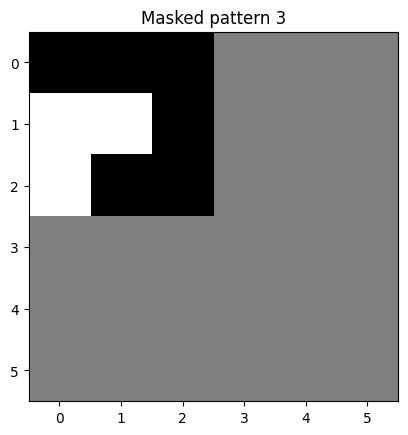

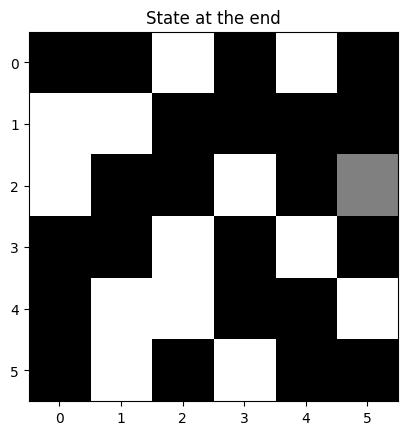

In [27]:
pattern_to_start = random_patterns['pattern_3']
partially_masked_pattern = apply_mask(pattern_to_start)

#reinitialise the state of the network, evolve it for several steps and then visualise 

HFN2 = HopfieldNetwork(random_patterns)

HFN2.set_state(partially_masked_pattern.ravel())
fig, ax = HFN2.visualise(title="Masked pattern 3")

for _ in range(199):
    HFN2.update_state()

fig, ax = HFN2.visualise(title="State at the end")

ending_state = HFN2.state
found = None
for n, p in random_patterns.items():
    if np.array_equal(p.ravel(), ending_state):
        print(f"Converged to {n}")
        found = True
        break

if not found:
    print("Did not converge to any known state")

plt.show()

It does converge to the staritng pattern but not always in 200 steps.

## Exercise 6.11 
The stored patterns are not the only fixed points of our dynamics. Prove analytically that also the negatives of the stored patterns (defined by $-x_i^{\mu}$) are fixed points of the dynamics. Then, check numerically the validity of this claim by starting from the negative of a stored pattern and evolving the system.

Converged to negative of pattern_4


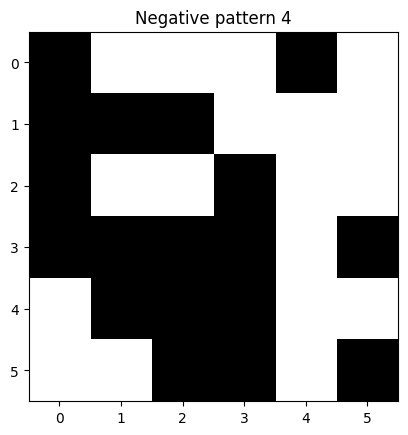

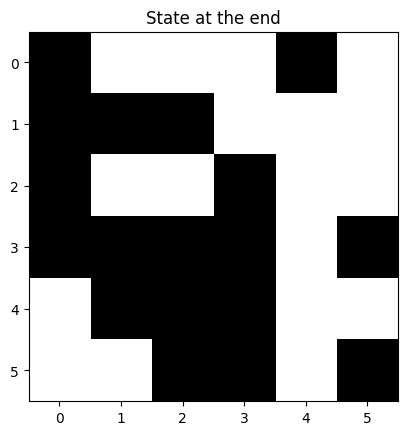

In [28]:
pattern = random_patterns['pattern_4']

negative_pattern = pattern * (-1)

#reinitialise the state of the network, evolve it for several steps and then visualise 

HFN3 = HopfieldNetwork(random_patterns)

HFN3.set_state(negative_pattern.ravel())
fig, ax = HFN3.visualise(title="Negative pattern 4")

for _ in range(199):
    HFN3.update_state()

fig, ax = HFN3.visualise(title="State at the end")

ending_state = HFN3.state
found = None
for n, p in random_patterns.items():
    if np.array_equal(p.ravel(), - ending_state):
        print(f"Converged to negative of {n}")
        found = True
        break

if not found:
    print("Did not converge to any known state or its negative")

plt.show()

So yes, also the negative of patterns is stored.

# Exercise 6.12 

What happens if we try to initialise the network in a mixed state? For example and mix of patterns 1, 2 and 3: 

$$ s_i(0) := x_i^{\textrm{mix}} = \textrm{sgn} \big( \pm x_i^{(1)} \pm x_i^{(2)} \pm x_i^{(3)} \big)$$


Did not converge to any known state or its negative


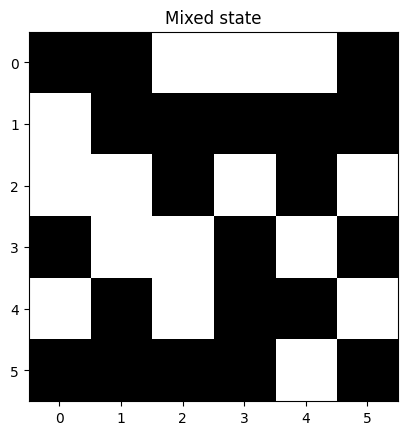

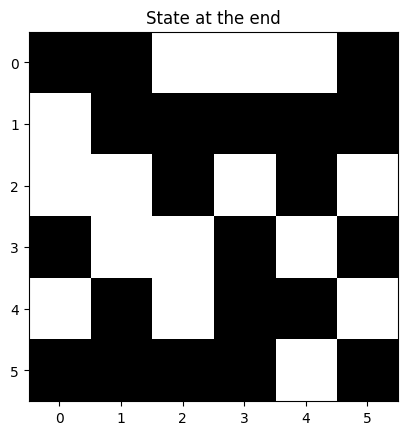

In [29]:
##### define a mixed state
mixed_state = np.sign(random_patterns['pattern_1'].flatten() - random_patterns['pattern_2'].flatten() + random_patterns['pattern_3'].flatten())

#reinitialise the state of the network, evolve it for several steps and then visualise 

HFN4 = HopfieldNetwork(random_patterns)

HFN4.set_state(mixed_state)
fig, ax = HFN4.visualise(title="Mixed state")

for _ in range(199):
    HFN4.update_state()

fig, ax = HFN4.visualise(title="State at the end")

ending_state = HFN4.state
found = None
for n, p in random_patterns.items():
    if np.array_equal(p.ravel(), ending_state) or np.array_equal(p.ravel(), -ending_state):
        print(f"Converged to {n} or its negative")
        found = True
        break

if not found:
    print("Did not converge to any known state or its negative")

plt.show()

# Exercise 6.13

The Hopfield Network has a storage capacity, meaning that if the number of stored patterns is too high for the number of neurons, it will show issues in correctly retrieving the patterns. 

The storage capacity for a classical Hopfield Network can be estimated as $C\approx\frac{N}{2\log_2 N}$.

Test a Hopfield network with a number of stored patterns way higher than its capacity (for instance try to store 20 patterns with 4x4 pixels) and show that it fails in retrieving these patterns.

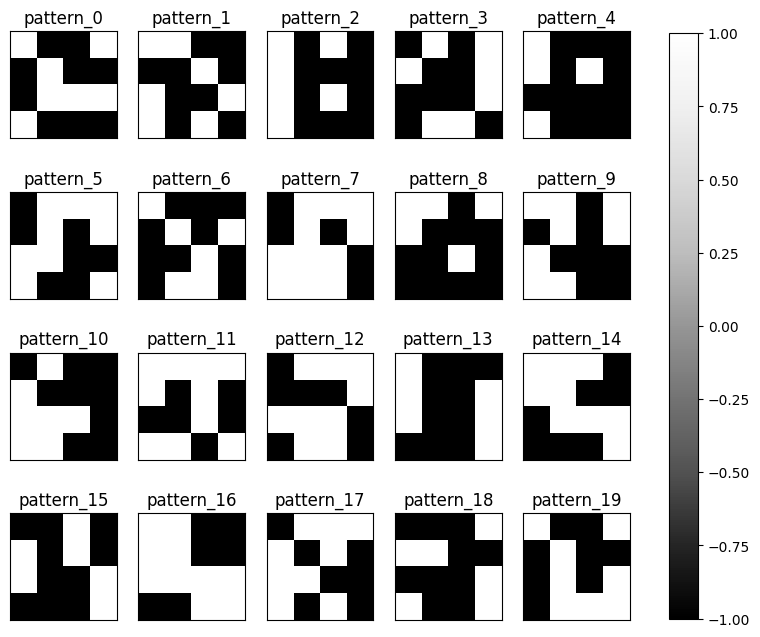

In [30]:
#Create 20 random patterns of size 4x4
N_patterns = 20
pattern_size = (4, 4)
random_patterns_20 = {
    f"pattern_{i}": np.random.choice([-1, 1], size=pattern_size)
    for i in range(N_patterns)
}

fig, ax = plot_patterns(random_patterns_20)

HFN_20 = HopfieldNetwork(random_patterns_20)

Not all the patterns are equally 'unstable', some of them will still act as fixed points, while other will not. Try different starting patterns among those stored and try to find a pattern which is 'stable' and one that is 'unstable'. 

In [31]:
# Try to start from all the stored patterns and find the stable or unstable ones.

for n, starting_pattern in random_patterns_20.items():
    HFN_20.set_state(starting_pattern.ravel())
    HFN_20.update_state(asynchronous=False)

    ending_state = HFN_20.state

    if np.array_equal(starting_pattern.ravel(), ending_state) or np.array_equal(starting_pattern.ravel(), -ending_state):
        print(f"{n} is stable")
    else:
        print(f"{n} is unstable")

plt.show()


pattern_0 is unstable
pattern_1 is unstable
pattern_2 is unstable
pattern_3 is unstable
pattern_4 is unstable
pattern_5 is unstable
pattern_6 is unstable
pattern_7 is stable
pattern_8 is unstable
pattern_9 is unstable
pattern_10 is unstable
pattern_11 is unstable
pattern_12 is unstable
pattern_13 is unstable
pattern_14 is unstable
pattern_15 is unstable
pattern_16 is unstable
pattern_17 is unstable
pattern_18 is unstable
pattern_19 is unstable


In [32]:
stable = []
for n, starting_pattern in random_patterns_20.items():
    start = starting_pattern.ravel().copy()
    HFN_20.set_state(start)

    for _ in range(150):
        prev = HFN_20.state.copy()
        HFN_20.update_state(asynchronous=False) 
        if np.array_equal(HFN_20.state.copy(), prev):
            break

    ending_state = HFN_20.state.copy()

    # Check if it's a fixed point
    if np.array_equal(start, ending_state) or np.array_equal(start, -ending_state):
        print(f"{n} is STABLE (fixed point)")
        stable.append(n)
    else:
        converged_to = None
        for m, candidate in random_patterns_20.items():
            if m == n:
                continue
            if np.array_equal(candidate.ravel(), ending_state) or np.array_equal(candidate.ravel(), -ending_state):
                converged_to = m
                break

        if converged_to is not None:
            print(f"{n} is UNSTABLE → converged to stored pattern {converged_to}")
        else:
            print(f"{n} is UNSTABLE → converged to a SPURIOUS attractor (not a stored pattern)")

print(f"\nTotal stable: {len(stable)} / {len(random_patterns_20)}")
print(f"Stable patterns: {stable}")

pattern_0 is UNSTABLE → converged to stored pattern pattern_7
pattern_1 is UNSTABLE → converged to stored pattern pattern_7
pattern_2 is UNSTABLE → converged to stored pattern pattern_7
pattern_3 is UNSTABLE → converged to stored pattern pattern_7
pattern_4 is UNSTABLE → converged to stored pattern pattern_7
pattern_5 is UNSTABLE → converged to stored pattern pattern_7
pattern_6 is UNSTABLE → converged to stored pattern pattern_7
pattern_7 is STABLE (fixed point)
pattern_8 is UNSTABLE → converged to stored pattern pattern_7
pattern_9 is UNSTABLE → converged to stored pattern pattern_7
pattern_10 is UNSTABLE → converged to stored pattern pattern_7
pattern_11 is UNSTABLE → converged to a SPURIOUS attractor (not a stored pattern)
pattern_12 is UNSTABLE → converged to stored pattern pattern_7
pattern_13 is UNSTABLE → converged to stored pattern pattern_7
pattern_14 is UNSTABLE → converged to stored pattern pattern_7
pattern_15 is UNSTABLE → converged to stored pattern pattern_7
pattern_16 

# The Classical Hopfield Networks fails with complex patterns


The network that we implemented is very good at recognising simple patterns, as long as you do not exceed the capacity of you network. But it will fail with more complex patterns.

In the next cell, we will load **more complex patterns**, namely a few sprites from the Pokemon videogames. These images are way bigger than the patterns previously used (120x112 pixels).

To convert the images from the *.png* format to matrices, we'll need a package called *openCV*. If not already installed on your system, you can easily install it by running

    pip install opencv-python

in your terminal.

In [33]:
import cv2
import os

directory = os.fsencode("complex_patterns")

complex_patterns = {}
      
for file in os.listdir(directory):
    filename = os.fsdecode(file)

    complex_patterns[filename[:-4]] = (cv2.imread("complex_patterns/" + filename, cv2.IMREAD_GRAYSCALE)/255)*2 - 1


In [34]:
# Initialise a new Hopfield network with the new patterns
HFN = HopfieldNetwork(complex_patterns)

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Energy evolution over 5 steps'}>)

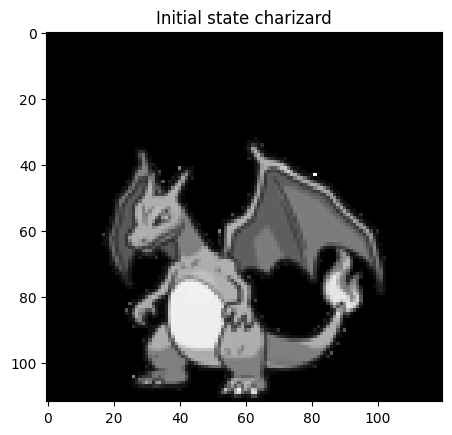

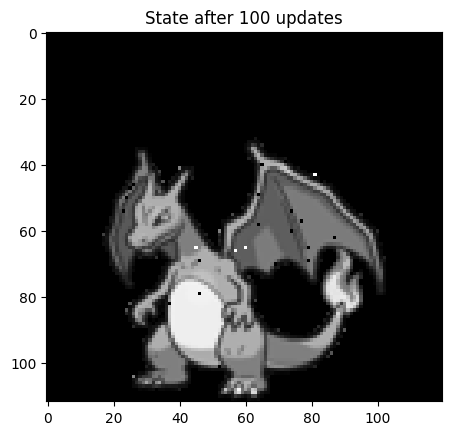

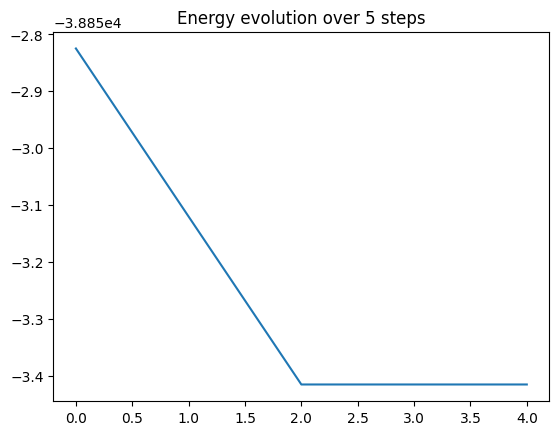

In [35]:
pokemon = 'charizard'

HFN.set_state(complex_patterns[pokemon].flatten()) #reinitialise the state of the network
HFN.visualise(title=f"Initial state {pokemon}")
for i in range(100):
    HFN.update_state(asynchronous=True)
HFN.visualise(title=f"State after {i+1} updates")

HFN.plot_energy(n_steps = 5)

You'll soon realize that **our Hopfield Network is not doing great with these more complex patterns**. There are probably two main reasons: the patterns are not binary (they are grayscale images, not black and white) and also they are **too correlated** , with a white/gray silhouette in the central-bottom part of the square surrounded by a large portion of black pixels.
It's time for an upgrade...

# Let's upgrade: Modern Hopfield Networks

The performances of the Hopfield Network can be greatly improved by just modifying the energy function and the update rule. 
The new rules are:

| | **Classic** | **Modern** |
| ----------- | ----------- | ----------- |
| **Update rule** | $ \vec{s} \leftarrow \textrm{sign}\big(\underbrace{\vec{x}\vec{x}^{\mathsf{T}}}_{\mathsf{J}}\vec{s}\big)$ | $\vec{s} \leftarrow \vec{x} \textrm{softmax}(\beta \vec{x}^{\mathsf{T}}\vec{s})$ |
| **Energy function** | $ E(\vec{s}) = \vec{s}^{\mathsf{T}}\underbrace{\vec{x}\vec{x}^{\mathsf{T}}}_{\mathsf{J}}\vec{s}$ | $E(\vec{s}) = -\textrm{lse}\big(\vec{x}^{\mathsf{T}}\vec{s}\big) + \frac{1}{2} \vec{s}^{\mathsf{T}}\vec{s}$ |

where the softmax function is defined as $\text{softmax}(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^{K}e^{x_j}}$ and the log-sum-exp function is $\text{lse}(\mathbf{x})=\log(\sum_{i=0}^{K}e^{x_i})$.

# Exercise 6.14 

Implement the *softmax* and *lse* functions, then complete the new class *ModernHopfieldNetwork* by defining the new energy function and update rule.

Finally, test your new model on the complex patterns and show that, starting from a random pattern, the system correctly converge to one of the Pokemon sprites.

In [36]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def log_sum_exp(x, beta = 0.01):
    max_x = np.max(x) # Numerical trick to prevent overflow
    # The LSE is scaled by 1/beta
    return max_x + (1/beta) * np.log(np.sum(np.exp(beta * (x - max_x))))

We want the new class to inherit all the methods from our original `HopfieldNetwork` class so we can use all the same plotting functions. Complete the *update_state* and *get_energy* methods.

In [37]:
class ModernHopfieldNetwork(HopfieldNetwork):
    def __init__(self,patterns,beta=0.01):
        self.beta = beta
        super().__init__(patterns)
    
    def update_state(self):
        """This is the ONLY difference between ModernHopfieldNetwork and HopfieldNetwork. Igt has a slightly different update rule.
        Note the use of a softmax function to make the network dynamics more continuous"""
        logits = self.flat_patterns @ self.state.copy()
        self.logits = logits
        self.state = softmax(self.beta * logits) @ self.flat_patterns
        self.save_history()
 
    def get_energy(self,state=None):
        state = self.state.copy() if state is None else state
        logits = self.flat_patterns @ state
        lse_term = log_sum_exp(logits, self.beta)
        norm_term = 0.5 * np.dot(state, state)
        
        return -lse_term + norm_term    

**Time to test the new network!** Initialise a Modern Hopfield Network using the complex patterns we imported. Then start from a random pattern and check if the system evolves towards one of the stored patterns. You can also plot the energy.

Converged to mew


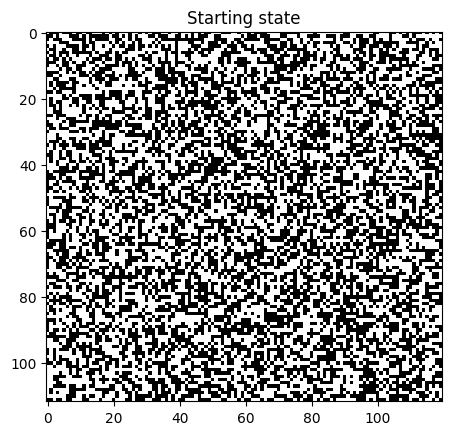

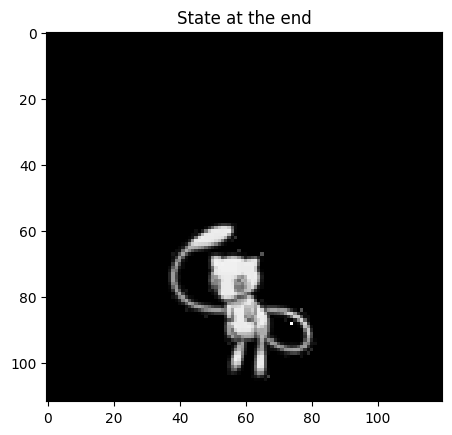

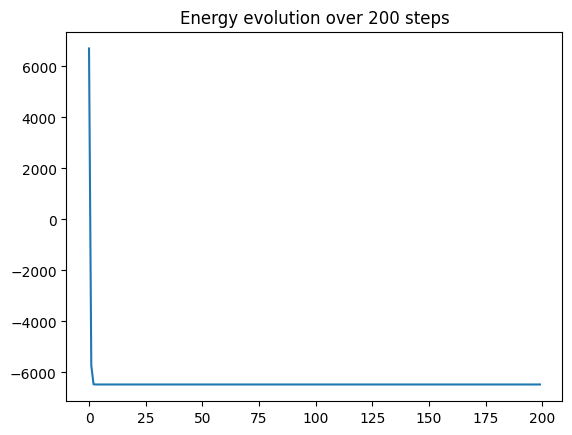

In [38]:
# reinitialise the state of the network, evolve it for several steps and then visualise 
MHFN = ModernHopfieldNetwork(complex_patterns)
pattern_size = complex_patterns['eevee'].shape

pattern_to_start = np.random.choice([-1, 1], size=pattern_size).ravel()

MHFN.set_state(pattern_to_start)
fig, ax = MHFN.visualise(title="Starting state")

for _ in range(199):
    MHFN.update_state()

fig, ax = MHFN.visualise(title="State at the end")

ending_state = MHFN.state.copy()
found = None
for n, p in complex_patterns.items():
    if np.allclose(p.ravel(), ending_state, atol=1e-3):
        print(f"Converged to {n}")
        found = True
        break

if not found:
    print("Did not converge to any known state")

MHFN.plot_energy(n_steps=200)
plt.show()

# Exercise 6.15

Like you did previously with simple patterns, show that our new Hopfield Network is able to recognize images even when they are noisy or when a large portion of the image is hidden/masked.


Converged to eevee (Similarity: 1.0000)


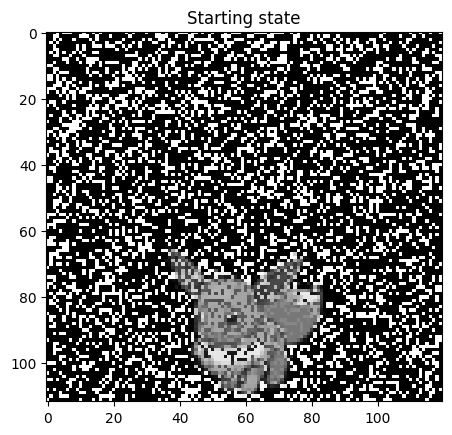

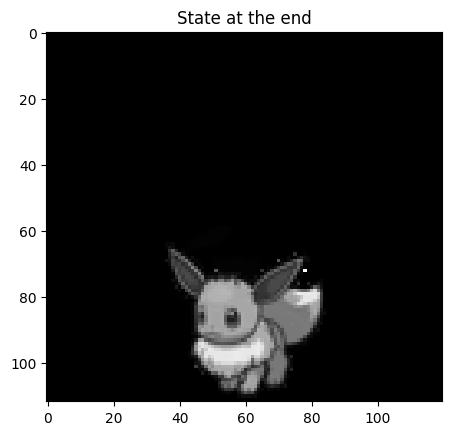

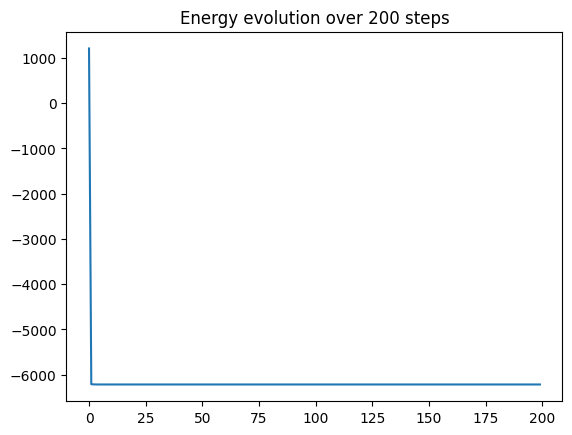

In [39]:
### START WITH THE NOISY PATTERN...
pattern_to_start = complex_patterns['eevee']

X = 30 # percentage of bits to flip 

noisy_state = pattern_to_start.ravel().copy()
idx = np.random.choice(pattern_to_start.size, int(pattern_to_start.size * X/100), replace=False)
noisy_state[idx] *= -1

# reinitialise the state of the network, evolve it for several steps and then visualise 
MHFN1 = ModernHopfieldNetwork(complex_patterns)
pattern_size = complex_patterns['eevee'].shape

MHFN1.set_state(noisy_state)
fig, ax = MHFN1.visualise(title="Starting state")

for _ in range(199):
    MHFN1.update_state()

fig, ax = MHFN1.visualise(title="State at the end")

# Use stored similarities with the patterns to determine if the state converged to one of the patterns
similarities = MHFN1.get_similarities()
best_pattern_idx = np.argmax(similarities)

if similarities[best_pattern_idx] > 0.99:
    pattern_name = list(complex_patterns.keys())[best_pattern_idx]
    print(f"Converged to {pattern_name} (Similarity: {similarities[best_pattern_idx]:.4f})")
else:
    print(f"Did not converge. Closest: {pattern_name} (similarity {similarities[best_pattern_idx]:.4f})")

MHFN1.plot_energy(n_steps=200)
plt.show()

Converged to mew with beta = 0.01


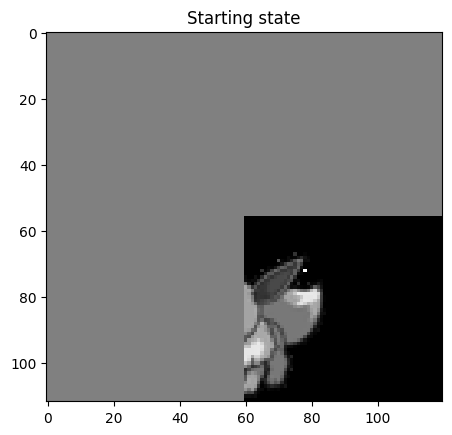

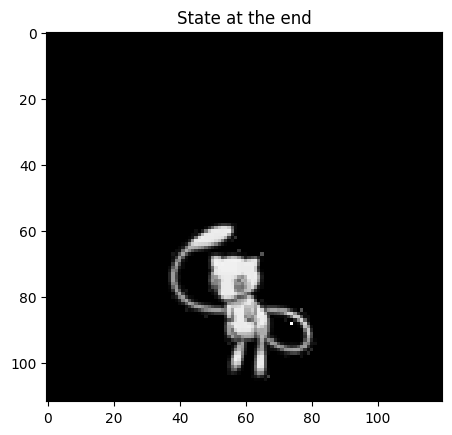

In [40]:
### ... NOW DO THE SAME WITH THE MASKED PATTERN
BETA = 0.01
pattern_to_start = complex_patterns['eevee']

mask = np.zeros_like(pattern_to_start) 
visible = np.ones((pattern_to_start.shape[0]//2, pattern_to_start.shape[1]//2))
mask[pattern_to_start.shape[0]//2:, pattern_to_start.shape[1]//2:] = visible
partially_masked_pattern = mask * pattern_to_start


MHFN2 = ModernHopfieldNetwork(complex_patterns, beta=BETA)
pattern_size = complex_patterns['eevee'].shape

MHFN2.set_state(partially_masked_pattern.ravel())
fig, ax = MHFN2.visualise(title="Starting state")

for _ in range(199):
    MHFN2.update_state()

fig, ax = MHFN2.visualise(title="State at the end")

similarities = MHFN2.get_similarities()
best_pattern_idx = np.argmax(similarities)

if similarities[best_pattern_idx] > 0.99:
    pattern_name = list(complex_patterns.keys())[best_pattern_idx]
    print(f"Converged to {pattern_name} with beta = {BETA}")
else:
    print(f"Did not converge. Closest: {pattern_name} (similarity {similarities[best_pattern_idx]:.4f})")

plt.show()

Converged to eevee with beta = 0.01064


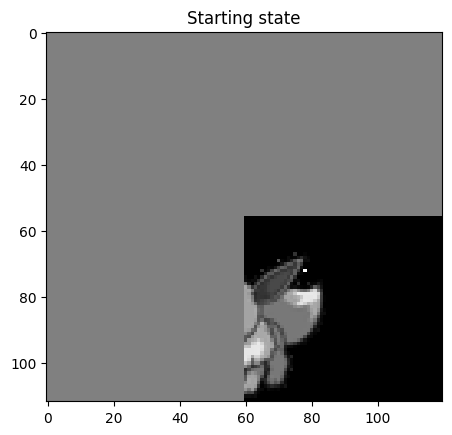

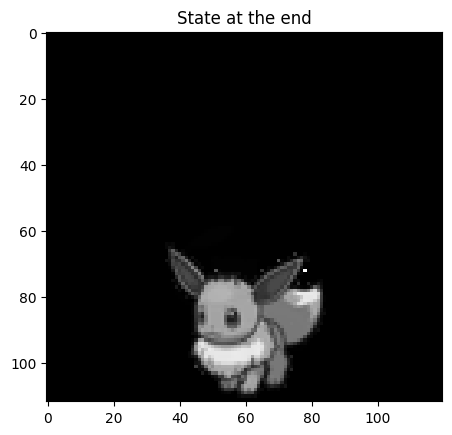

In [41]:
### ... NOW DO THE SAME WITH THE MASKED PATTERN
BETA = 0.01064 # smallest beta found that divides the model converging to mew and eve (under it converges to mew)
pattern_to_start = complex_patterns['eevee']

mask = np.zeros_like(pattern_to_start) 
visible = np.ones((pattern_to_start.shape[0]//2, pattern_to_start.shape[1]//2))
mask[pattern_to_start.shape[0]//2:, pattern_to_start.shape[1]//2:] = visible
partially_masked_pattern = mask * pattern_to_start


MHFN2 = ModernHopfieldNetwork(complex_patterns, beta=BETA)
pattern_size = complex_patterns['eevee'].shape

MHFN2.set_state(partially_masked_pattern.ravel())
fig, ax = MHFN2.visualise(title="Starting state")

for _ in range(199):
    MHFN2.update_state()

fig, ax = MHFN2.visualise(title="State at the end")

similarities = MHFN2.get_similarities()
best_pattern_idx = np.argmax(similarities)

if similarities[best_pattern_idx] > 0.99:
    pattern_name = list(complex_patterns.keys())[best_pattern_idx]
    print(f"Converged to {pattern_name} with beta = {BETA}")
else:
    print(f"Did not converge. Closest: {pattern_name} (similarity {similarities[best_pattern_idx]:.4f})")
    
plt.show()

Converged to eevee with beta = 0.05


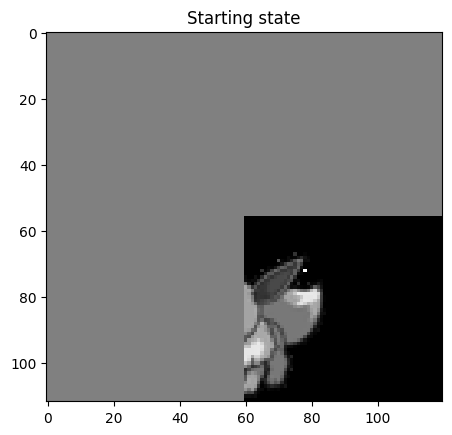

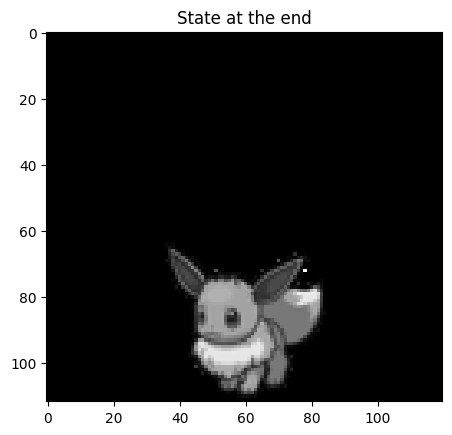

In [42]:
### ... NOW DO THE SAME WITH THE MASKED PATTERN
BETA = 0.05
pattern_to_start = complex_patterns['eevee']

mask = np.zeros_like(pattern_to_start) 
visible = np.ones((pattern_to_start.shape[0]//2, pattern_to_start.shape[1]//2))
mask[pattern_to_start.shape[0]//2:, pattern_to_start.shape[1]//2:] = visible
partially_masked_pattern = mask * pattern_to_start


MHFN2 = ModernHopfieldNetwork(complex_patterns, beta=BETA)
pattern_size = complex_patterns['eevee'].shape

MHFN2.set_state(partially_masked_pattern.ravel())
fig, ax = MHFN2.visualise(title="Starting state")

for _ in range(199):
    MHFN2.update_state()

fig, ax = MHFN2.visualise(title="State at the end")

similarities = MHFN2.get_similarities()
best_pattern_idx = np.argmax(similarities)

if similarities[best_pattern_idx] > 0.99:
    pattern_name = list(complex_patterns.keys())[best_pattern_idx]
    print(f"Converged to {pattern_name} with beta = {BETA}")
else:
    print(f"Did not converge. Closest: {pattern_name} (similarity {similarities[best_pattern_idx]:.4f})")
    
plt.show()

# Exercise 6.16

In the update function for the Modern Hopfield Network we use a scalar quantity called $\beta$, a sort of inverse temperature.

Try to evolve a random state with the Modern Hopfield Network using a very high temperature, for instance $\beta \leftarrow 0.001$. What do you see?

If everything you did is correct, you should see that at high temperature the network evolves towards metastable states. Can you briefly explain why you see this behaviour?



The network evolves towards a "blurry" or "ghostly" state that looks like a mixture of several stored patterns rather than a single, clear image.

Why this happens:
In the update rule, $\beta$ controls how "sharp" the softmax is. When $\beta$ is very small (high temperature), the softmax assigns nearly equal weights to all stored patterns instead of picking the most similar one. Consequently, the network settles into a weighted average of the patterns. In terms of energy, the high temperature flattens the landscape, merging distinct "basins of attraction" into a single, shallow well.

Did not converge. Closest: eevee (similarity 0.9740)


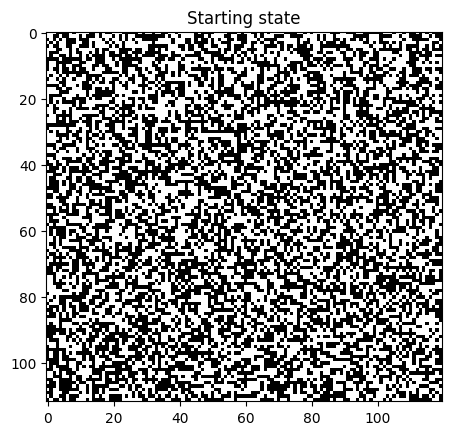

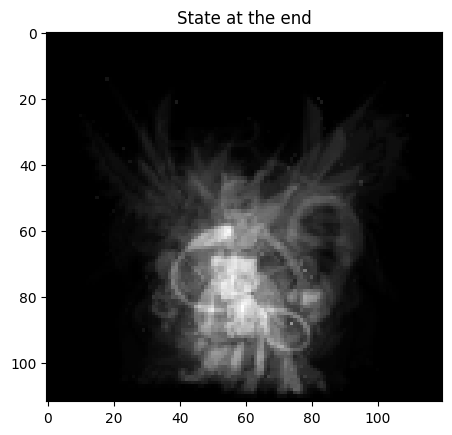

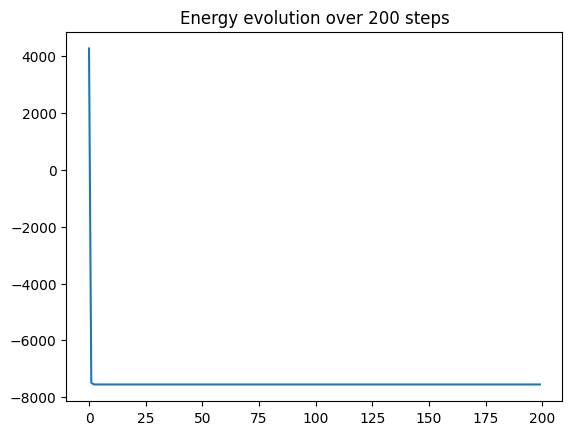

In [43]:
BETA = 0.001
random_start = np.random.choice([-1, 1], size=pattern_size).ravel()

MHFN5 = ModernHopfieldNetwork(complex_patterns, beta=BETA)
pattern_size = complex_patterns['eevee'].shape

MHFN5.set_state(random_start)
fig, ax = MHFN5.visualise(title="Starting state")

for _ in range(199):
    MHFN5.update_state()

fig, ax = MHFN5.visualise(title="State at the end")

similarities = MHFN5.get_similarities()
best_pattern_idx = np.argmax(similarities)

if similarities[best_pattern_idx] > 0.99:
    pattern_name = list(complex_patterns.keys())[best_pattern_idx]
    print(f"Converged to {pattern_name} (Similarity: {similarities[best_pattern_idx]:.4f})")
else:
    print(f"Did not converge. Closest: {pattern_name} (similarity {similarities[best_pattern_idx]:.4f})")
    
MHFN5.plot_energy(n_steps=200)
plt.show()